<a href="https://colab.research.google.com/github/SergeiVKalinin/Probabilistic-Unmixing-0/blob/main/notebooks/04_Heterogeneous_Component_Uncertainty.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04 — Heterogeneous Uncertainty Across Components

Real experiments rarely provide equally precise information for every component.

This notebook constructs four deliberately different information regimes:

| Component | Concentration knowledge | Spectral knowledge |
|---|---|---|
| 1 | good | good |
| 2 | good | poor |
| 3 | poor | good |
| 4 | poor | poor |

The underlying physical experiment is shared by all three unmixing levels. Only the prior uncertainty assigned to each component differs.

This example is useful for learning how concentration information and spectral information complement one another.

In [ ]:
!pip install -q --force-reinstall --no-deps git+https://github.com/SergeiVKalinin/Probabilistic-Unmixing-0.git

import numpy as np
import matplotlib.pyplot as plt
import probunmix as pu

print("probunmix version:", pu.__version__)

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
probunmix version: 0.1.0


## Generate the heterogeneous benchmark

Concentration uncertainty is specified directly as a component-specific standard deviation. Spectral uncertainty is a relative multiplier of the canonical Level 1 and Level 2 prior widths.

Probabilistic Unmixing Dataset

Dimensions
----------
Locations:          60
Spectral channels:  140
Components:         4

Spectral data
-------------
Spectral axis:      0 to 12
Measured intensity: -0.01567 to 0.8685

Composition / mixture fractions
-------------------------------
Row-sum range:      1.000000 to 1.000000
Mean row sum:       1.000000

Available spectral knowledge
----------------------------
Level 0 fixed spectra:      YES
Level 1 parametric prior:   YES
Level 2 functional library: YES

Evaluation information
----------------------
Synthetic truth:            YES


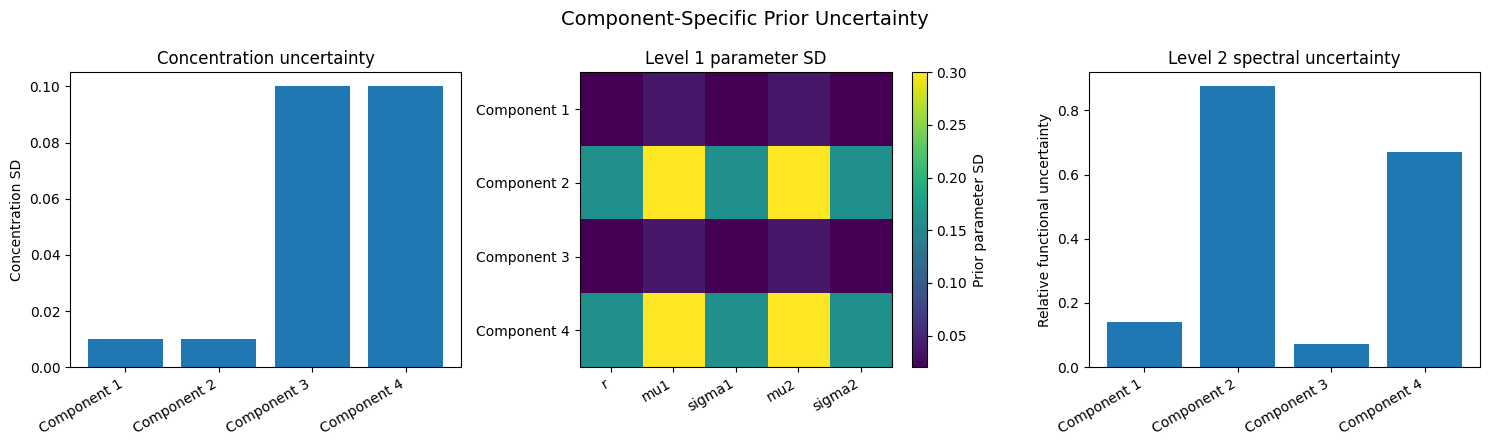

In [ ]:
concentration_uncertainty = [0.01, 0.01, 0.10, 0.10]
spectral_uncertainty = [0.25, 2.00, 0.25, 2.00]

data = pu.generate_example(
    n_locations=60,
    n_channels=140,
    n_library=120,
    concentration_uncertainty=concentration_uncertainty,
    spectral_uncertainty=spectral_uncertainty,
    seed=42,
)

pu.validate_data(data)
pu.print_data_summary(data)
pu.plot_uncertainty_structure(data);

## Run all three knowledge levels

The observed spectra, measurement noise, and hidden physical truth are identical. Level 0, Level 1, and Level 2 differ only in how the endmember spectra are represented.

In [ ]:
result0 = pu.fit(data, level=0, n_draws=800, seed=100)

result1 = pu.fit(
    data, level=1, n_draws=800, seed=101, max_nfev=250
)

result2 = pu.fit(
    data, level=2, n_draws=800, seed=102, max_nfev=250
)

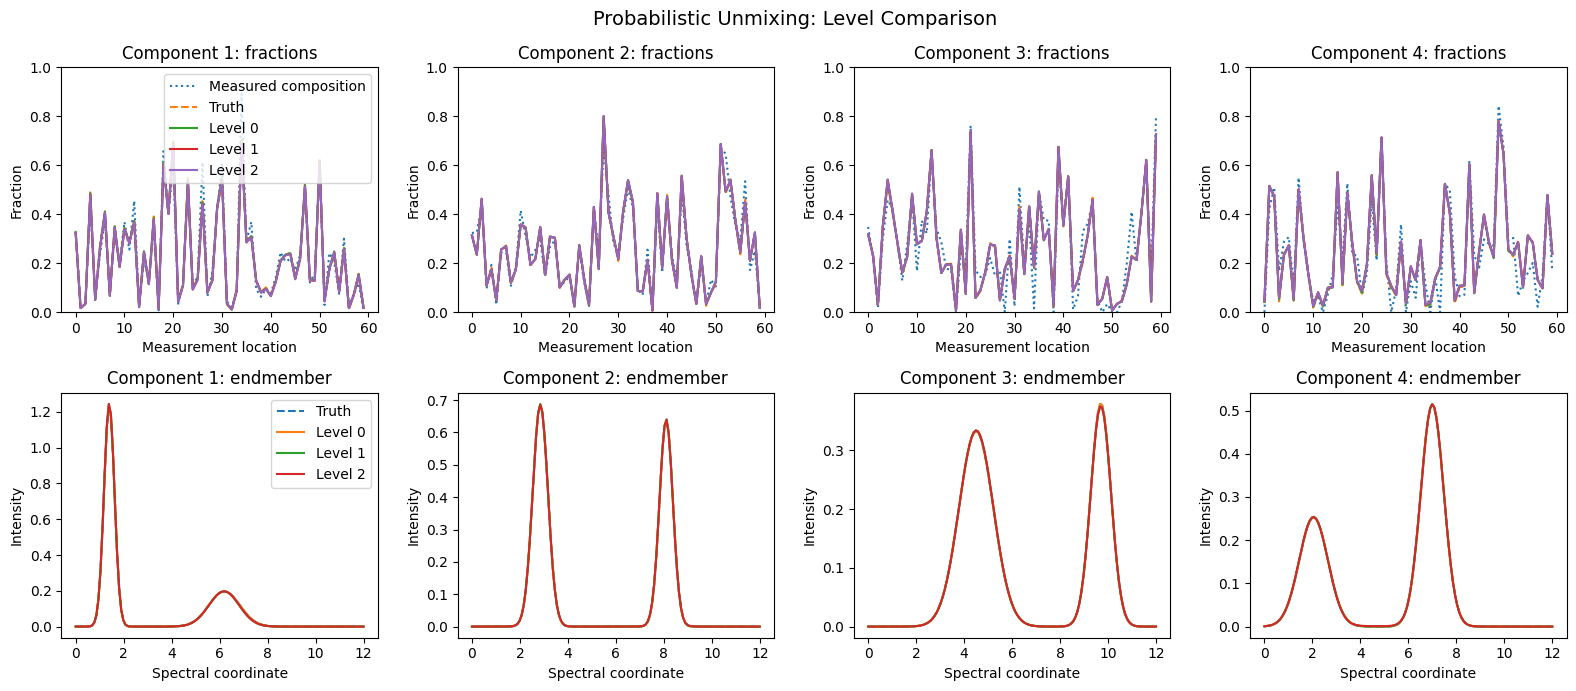

In [ ]:
pu.plot_level_comparison(
    data,
    result0,
    result1,
    result2,
);

## Compare the four components numerically

The table separates recovery error from posterior uncertainty. This matters because a narrow posterior is not automatically an accurate posterior.

In [ ]:
import pandas as pd

results = [result0, result1, result2]
regime = [
    "W good / S good",
    "W good / S poor",
    "W poor / S good",
    "W poor / S poor",
]

rows = []
for k in range(data.n_components):
    row = {
        "component": k + 1,
        "regime": regime[k],
        "input_W_sigma": data.W_sigma[:, k].mean(),
    }

    for result in results:
        L = result.level
        row[f"L{L}_W_RMSE"] = np.sqrt(
            np.mean((result.W_mean[:, k] - data.W_true[:, k])**2)
        )
        row[f"L{L}_W_SD"] = result.W_sd[:, k].mean()
        row[f"L{L}_S_RMSE"] = np.sqrt(
            np.mean((result.S_mean[k] - data.S_true[k])**2)
        )
        row[f"L{L}_S_SD"] = result.S_sd[k].mean()

    rows.append(row)

component_metrics = pd.DataFrame(rows)
component_metrics

,component,regime,input_W_sigma,L0_W_RMSE,L0_W_SD,L0_S_RMSE,L0_S_SD,L1_W_RMSE,L1_W_SD,L1_S_RMSE,L1_S_SD,L2_W_RMSE,L2_W_SD,L2_S_RMSE,L2_S_SD
0,1,W good / S good,0.01,0.004574,0.005145,0.0,0.0,0.006928,0.005377,0.003222,0.000964,0.007008,0.005405,0.003200,0.000960
1,2,W good / S poor,0.01,0.004514,0.005003,0.0,0.0,0.004490,0.005156,0.001119,0.000611,0.004653,0.005247,0.001374,0.001010
2,3,W poor / S good,0.10,0.005307,0.004964,0.0,0.0,0.005438,0.005013,0.001161,0.000657,0.005401,0.005020,0.001149,0.000683
3,4,W poor / S poor,0.10,0.005302,0.006360,0.0,0.0,0.006362,0.006713,0.000544,0.000962,0.006188,0.006799,0.000963,0.001618


## Interpretation

Focus especially on Components 2 and 3:

- Component 2 has good concentration information but poor spectral information.
- Component 3 has poor concentration information but good spectral information.

Their comparison reveals whether the two information sources are interchangeable, complementary, or asymmetric for this inverse problem.

Component 4 is the deliberately difficult case: both sources of prior information are weak.